In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('segmentation data.csv')

In [3]:
df.head(10)

,ID,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
0,100000001,0,0,67,2,124670,1,2
1,100000002,1,1,22,1,150773,1,2
2,100000003,0,0,49,1,89210,0,0
3,100000004,0,0,45,1,171565,1,1
4,100000005,0,0,53,1,149031,1,1
5,100000006,0,0,35,1,144848,0,0
6,100000007,0,0,53,1,156495,1,1
7,100000008,0,0,35,1,193621,2,1
8,100000009,0,1,61,2,151591,0,0
9,100000010,0,1,28,1,174646,2,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   ID               2000 non-null   int64
 1   Sex              2000 non-null   int64
 2   Marital status   2000 non-null   int64
 3   Age              2000 non-null   int64
 4   Education        2000 non-null   int64
 5   Income           2000 non-null   int64
 6   Occupation       2000 non-null   int64
 7   Settlement size  2000 non-null   int64
dtypes: int64(8)
memory usage: 125.1 KB


In [5]:
df.shape

(2000, 8)

In [6]:
df.describe()

,ID,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
count,2.000000e+03,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1.000010e+08,0.457000,0.496500,35.909000,1.03800,120954.419000,0.810500,0.739000
std,5.774946e+02,0.498272,0.500113,11.719402,0.59978,38108.824679,0.638587,0.812533
min,1.000000e+08,0.000000,0.000000,18.000000,0.00000,35832.000000,0.000000,0.000000
25%,1.000005e+08,0.000000,0.000000,27.000000,1.00000,97663.250000,0.000000,0.000000
50%,1.000010e+08,0.000000,0.000000,33.000000,1.00000,115548.500000,1.000000,1.000000
75%,1.000015e+08,1.000000,1.000000,42.000000,1.00000,138072.250000,1.000000,1.000000
max,1.000020e+08,1.000000,1.000000,76.000000,3.00000,309364.000000,2.000000,2.000000


In [7]:
df.drop(columns='ID',inplace=True)

In [8]:
df.isnull().sum().sort_values(ascending=False)

Sex                0
Marital status     0
Age                0
Education          0
Income             0
Occupation         0
Settlement size    0
dtype: int64

In [9]:
from sklearn.preprocessing import RobustScaler
scale=RobustScaler()
for col in df.columns:
 df[col]=scale.fit_transform(df[[col]])

In [10]:
from itertools import combinations
pair=list(combinations(df.columns,2))
pair

[('Sex', 'Marital status'),
 ('Sex', 'Age'),
 ('Sex', 'Education'),
 ('Sex', 'Income'),
 ('Sex', 'Occupation'),
 ('Sex', 'Settlement size'),
 ('Marital status', 'Age'),
 ('Marital status', 'Education'),
 ('Marital status', 'Income'),
 ('Marital status', 'Occupation'),
 ('Marital status', 'Settlement size'),
 ('Age', 'Education'),
 ('Age', 'Income'),
 ('Age', 'Occupation'),
 ('Age', 'Settlement size'),
 ('Education', 'Income'),
 ('Education', 'Occupation'),
 ('Education', 'Settlement size'),
 ('Income', 'Occupation'),
 ('Income', 'Settlement size'),
 ('Occupation', 'Settlement size')]

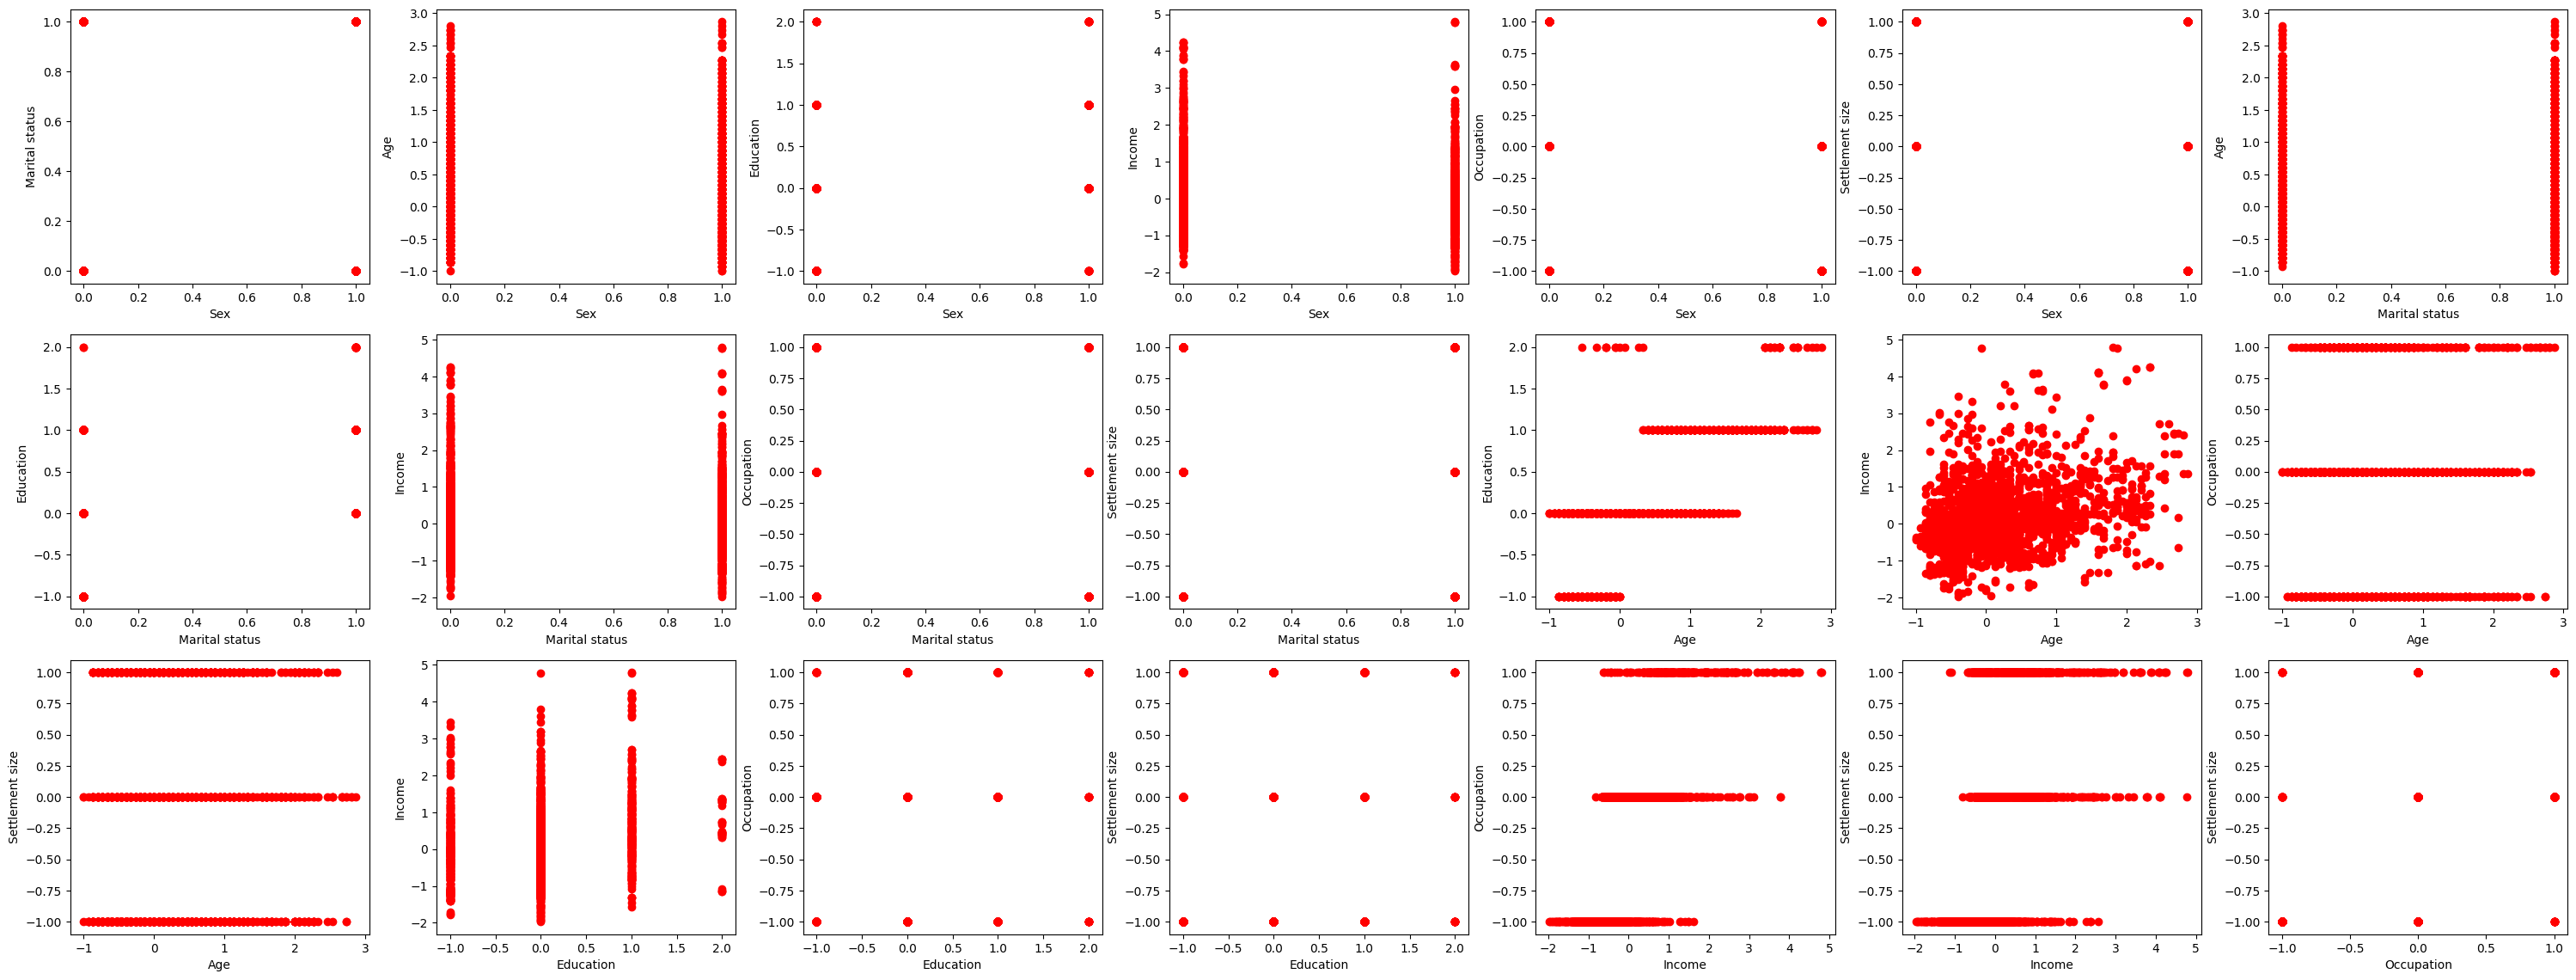

In [11]:
import matplotlib.pyplot as plt
plt.figure(figsize=(30,30))
for i, (f1 , f2) in enumerate(pair , 1):
  plt.subplot(8 ,7 , i)
  plt.scatter(df[f1] ,df[f2] ,c='r')
  plt.xlabel(f1)
  plt.ylabel(f2)
plt.tight_layout()
plt.show()

In [12]:
# age income
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
results = {}
for f1,f2 in pair:
    best_score=-1
    best_k=None
    for k in range(2,11):
        mod = KMeans(n_clusters=k,random_state=42)
        label = mod.fit_predict(df[[f1,f2]])
        score=silhouette_score(df[[f1,f2]],label)
        if score > best_score:
            best_score=score
            best_k=k
    results[(f1, f2)] = (best_k, best_score)
best_pair = max(results, key=lambda x: results[x][1])
print(f"أفضل اتنين Features: {best_pair} بعدد كلسترز {results[best_pair][0]} والـ Silhouette = {results[best_pair][1]:.3f}")


c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:1389: ConvergenceWarning: Number of distinct clusters (4) found smaller than n_clusters (5). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:1389: ConvergenceWarning: Number of distinct clusters (4) found smaller than n_clusters (6). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:1389: ConvergenceWarning: Number of distinct clusters (4) found smaller than n_clusters (7). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:1389: ConvergenceWarning: Number of distinct clusters (4) found smaller than n_clusters (8). Possibly due to

أفضل اتنين Features: ('Sex', 'Marital status') بعدد كلسترز 4 والـ Silhouette = 1.000


c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:1389: ConvergenceWarning: Number of distinct clusters (9) found smaller than n_clusters (10). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


In [22]:
score=[]
elbow=[]
for k in range(2,11):
    model = KMeans(n_clusters=k,random_state=42)
    y_pred = model.fit_predict(df[['Age' , 'Income']])
    score.append(silhouette_score(df[['Age' , 'Income']],y_pred))
    elbow.append(model.inertia_)

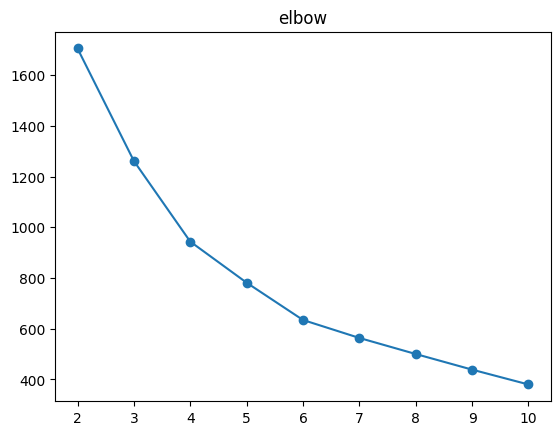

In [33]:
plt.plot(range(2,11),elbow,marker='o')
plt.title('elbow')
plt.show()

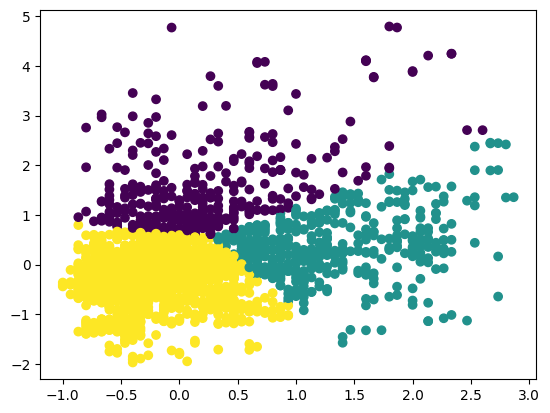

In [46]:
km = KMeans(n_clusters=3)
km.fit(df[['Age' , 'Income']])
y_pred = km.predict(df[['Age' , 'Income']])
plt.scatter(df['Age'] , df['Income'] , c=y_pred)
plt.show()

In [47]:
score=silhouette_score(df[['Age' , 'Income']],y_pred)
score

np.float64(0.4371201871293779)

In [36]:
# from sklearn.decomposition import PCA

# # تطبيق PCA على كل الداتا
# pca = PCA(n_components=2)
# df_pca = pca.fit_transform(df)

# # تحويل الناتج إلى DataFrame علشان يبقى سهل التعامل
# df_pca = pd.DataFrame(df_pca, columns=['PC1', 'PC2'])

# # رسم Scatter للـ PCA
# plt.scatter(df_pca['PC1'], df_pca['PC2'], c='r')
# plt.xlabel("PC1")
# plt.ylabel("PC2")
# plt.title("PCA - Reduced to 2 Components")
# plt.show()


In [37]:
# from sklearn.cluster import KMeans
# from sklearn.metrics import silhouette_score

# best_score = -1
# best_k = None

# for k in range(2, 11):
#     mod = KMeans(n_clusters=k, random_state=42)
#     labels = mod.fit_predict(df_pca)   # نستخدم الـ PC1 و PC2 بدل كل الأعمدة
#     score = silhouette_score(df_pca, labels)
#     if score > best_score:
#         best_score = score
#         best_k = k

# print(f"أفضل k على الـ PCA: {best_k} بـ Silhouette = {best_score:.3f}")


In [38]:
# km = KMeans(n_clusters=best_k, random_state=42)
# labels = km.fit_predict(df_pca)

# plt.scatter(df_pca['PC1'], df_pca['PC2'], c=labels, cmap='viridis')
# plt.xlabel("PC1")
# plt.ylabel("PC2")
# plt.title(f"PCA + KMeans Clustering (k={best_k})")
# plt.show()


In [39]:
# from sklearn.cluster import KMeans
# from sklearn.metrics import silhouette_score

# best_score = -1
# best_k = None

# # جرّب k من 2 لحد 10
# for k in range(2, 11):
#     km = KMeans(n_clusters=k, random_state=42)
#     labels = km.fit_predict(df[['Sex',	'Marital status']])   # هنا بنستخدم كل الأعمدة مش بس 2
#     score = silhouette_score(df, labels)
#     if score > best_score:
#         best_score = score
#         best_k = k

# print(f"أفضل k = {best_k} والـ Silhouette = {best_score:.3f}")


In [40]:
# from sklearn.decomposition import PCA
# import matplotlib.pyplot as plt

# pca = PCA(n_components=2)
# df_pca = pca.fit_transform(df)

# plt.scatter(df_pca[:,0], df_pca[:,1], c=labels, cmap='viridis')
# plt.xlabel("PC1")
# plt.ylabel("PC2")
# plt.title("Clustering with PCA Visualization")
# plt.show()


In [41]:
# from mpl_toolkits.mplot3d import Axes3D

# pca = PCA(n_components=3)
# df_pca = pca.fit_transform(df)


# fig = plt.figure(figsize=(8,6))
# ax = fig.add_subplot(111, projection='3d')
# ax.scatter(df_pca[:,0], df_pca[:,1], df_pca[:,2], c=labels, cmap='viridis')
# ax.set_xlabel("PC1")
# ax.set_ylabel("PC2")
# ax.set_zlabel("PC3")
# plt.title("3D PCA Clustering")
# plt.show()
